# Calibration-frame bias check

Tobii calibrates at the start of each EVE recording. Hypothesis: the first ~20 of the 90 `center`-camera frames are more likely to be (a) flagged invalid and (b) biased toward the screen center, because calibration fixations are typically shown near/around the screen center and gaze estimates during calibration are less reliable.

This uses `EveBundle.get_screen_intercept(exp_key, eye)` (new gaze-ray accessor, F-GAZE-RAY) to project the normalized-space gaze ray onto the screen plane (`z=0`) in both mm and px, plus `get_gaze_ray(...)["validity"]` and `get_frame_validity(exp_key)` for the validity signal. No new geometry is derived here — both the ray and the screen intercept are computed entirely inside `evedataset`; this notebook only aggregates and plots what the accessor returns.

Screen center is taken as `(960, 540)` px — half of EVE's native 1920×1080 stimulus resolution — which the median `hit_px` across a large sample confirms empirically (see below).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from evedataset import EveBundle

EVEDATASET_REPO = Path.cwd().parent.parent / "eve_shared" / "EveDataset"
BUNDLE_DIR = EVEDATASET_REPO / "bundle"

bundle = EveBundle.load(BUNDLE_DIR)

SCREEN_CENTER_PX = np.array([960.0, 540.0])  # EVE native stimulus resolution / 2
N_FRAMES = 90

gaze_ray_exp_keys = [ek for ek in bundle.samples_df["exp_key"] if bundle.has_gaze_ray(ek)]
print(f"{len(gaze_ray_exp_keys)} exp_keys have gaze-ray coverage")

2487 exp_keys have gaze-ray coverage


## Build a long-format table: (exp_key, patch, frame, distance_px, validity)

Sampled subset (seed 42) for tractable plotting; both `left`/`right` eye patches pooled (F-FLIP's canonical-eye convention doesn't apply here — we're checking raw screen-space bias, not training input).

In [2]:
rng = np.random.default_rng(42)
N_SAMPLE = 300
sample_exp_keys = rng.choice(gaze_ray_exp_keys, size=min(N_SAMPLE, len(gaze_ray_exp_keys)), replace=False)

rows = []
for ek in sample_exp_keys:
    frame_validity = bundle.get_frame_validity(ek)  # (90,) bool
    for patch in ("left", "right"):
        ray = bundle.get_gaze_ray(ek, patch)
        intercept = bundle.get_screen_intercept(ek, patch)
        dist_px = np.linalg.norm(intercept["hit_px"] - SCREEN_CENTER_PX, axis=1)
        valid = ray["validity"] & frame_validity
        for frame in range(N_FRAMES):
            rows.append((ek, patch, frame, dist_px[frame], bool(valid[frame])))

df = pd.DataFrame(rows, columns=["exp_key", "patch", "frame", "dist_px", "valid"])
print(f"{len(df)} rows ({df['exp_key'].nunique()} exp_keys x 2 patches x {N_FRAMES} frames)")
print(f"overall validity rate: {df['valid'].mean():.1%}")
df.head()

54000 rows (300 exp_keys x 2 patches x 90 frames)
overall validity rate: 93.4%


,exp_key,patch,frame,dist_px,valid
0,train31_step058,left,0,721.942766,False
1,train31_step058,left,1,721.972923,False
2,train31_step058,left,2,722.112182,False
3,train31_step058,left,3,722.169847,False
4,train31_step058,left,4,722.065406,False


## Validity rate vs frame index

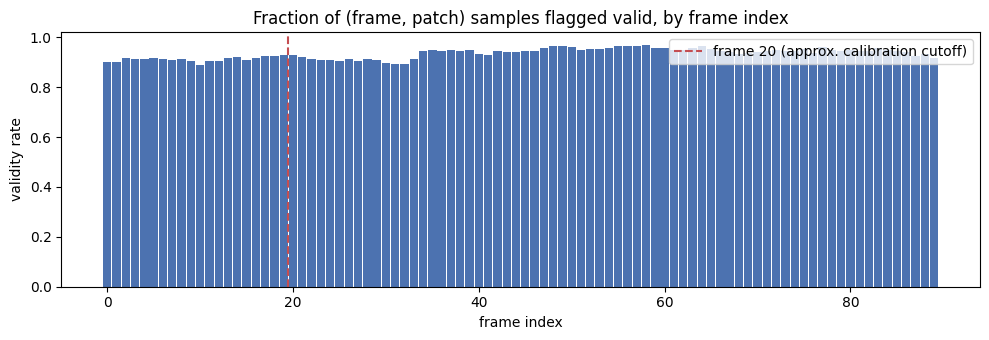

In [3]:
validity_by_frame = df.groupby("frame")["valid"].mean()

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(validity_by_frame.index, validity_by_frame.values, width=0.9, color="#4C72B0")
ax.axvline(19.5, color="#C44E52", linestyle="--", linewidth=1.5, label="frame 20 (approx. calibration cutoff)")
ax.set_xlabel("frame index")
ax.set_ylabel("validity rate")
ax.set_title("Fraction of (frame, patch) samples flagged valid, by frame index")
ax.set_ylim(0, 1.02)
ax.legend()
fig.tight_layout()
plt.show()

## Distance of the screen intercept to the screen center, vs frame index (violin)

Valid samples only — an invalid ray's intercept isn't a meaningful screen position. Frames are binned in groups of 5 (18 violins across 90 frames) for a readable plot; the calibration cutoff at frame 20 falls on a bin boundary.

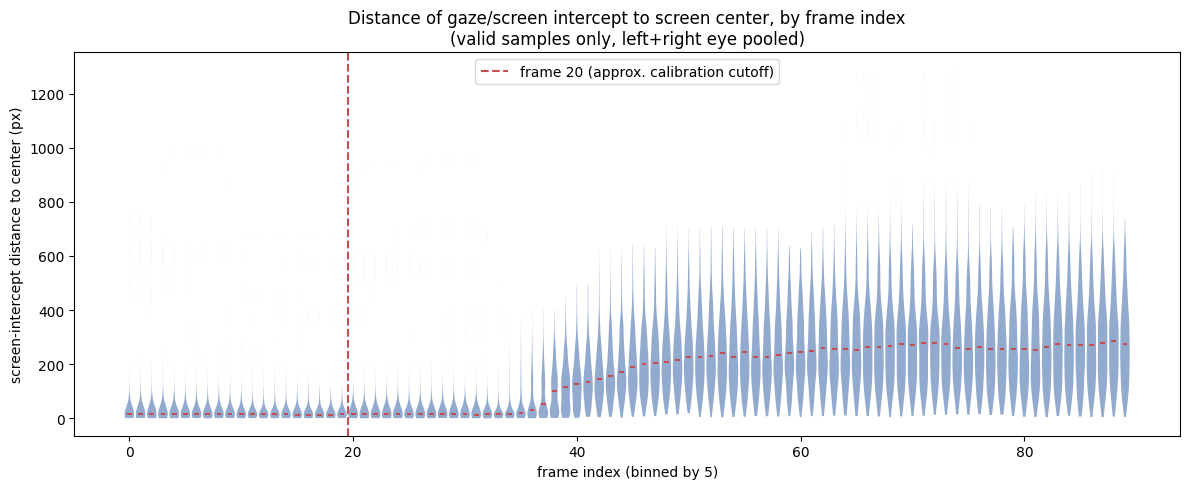

In [4]:
BIN_SIZE = 1
valid_df = df[df["valid"]].copy()
valid_df["frame_bin"] = (valid_df["frame"] // BIN_SIZE) * BIN_SIZE

bins = sorted(valid_df["frame_bin"].unique())
data = [valid_df.loc[valid_df["frame_bin"] == b, "dist_px"].values for b in bins]

fig, ax = plt.subplots(figsize=(12, 5))
parts = ax.violinplot(data, positions=bins, widths=BIN_SIZE * 0.85, showmedians=True, showextrema=False)
for body in parts["bodies"]:
    body.set_facecolor("#4C72B0")
    body.set_alpha(0.6)
parts["cmedians"].set_color("#C44E52")

ax.axvline(19.5, color="#C44E52", linestyle="--", linewidth=1.5, label="frame 20 (approx. calibration cutoff)")
ax.set_xlabel("frame index (binned by 5)")
ax.set_ylabel("screen-intercept distance to center (px)")
ax.set_title("Distance of gaze/screen intercept to screen center, by frame index\n(valid samples only, left+right eye pooled)")
ax.legend()
fig.tight_layout()
plt.show()

## Summary: first 20 frames vs the rest

In [5]:
calib_mask = df["frame"] < 20

print("Validity rate:")
print(f"  frames  0-19: {df.loc[calib_mask, 'valid'].mean():.1%}")
print(f"  frames 20-89: {df.loc[~calib_mask, 'valid'].mean():.1%}")

valid_calib = df[calib_mask & df["valid"]]["dist_px"]
valid_rest = df[~calib_mask & df["valid"]]["dist_px"]
print("\nMedian screen-intercept distance to center (valid samples):")
print(f"  frames  0-19: {valid_calib.median():.1f} px  (n={len(valid_calib)})")
print(f"  frames 20-89: {valid_rest.median():.1f} px  (n={len(valid_rest)})")

Validity rate:
  frames  0-19: 91.2%
  frames 20-89: 94.0%

Median screen-intercept distance to center (valid samples):
  frames  0-19: 14.5 px  (n=10950)
  frames 20-89: 171.7 px  (n=39492)
